In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
np.random.seed(78)  

In [9]:
n = 200  # number of records

data = {
    "Order_ID": np.arange(1, n+1),
    "Product_Category": np.random.choice(["Electronics", "Clothing", "Home", "Books"], n),
    "Price": np.random.randint(100, 5000, n),
    "Quantity": np.random.randint(1, 10, n),
    "Discount": np.round(np.random.uniform(0, 0.3, n), 2),
    "Customer_Rating": np.round(np.random.uniform(1, 5, n), 1)
}

df = pd.DataFrame(data)

# Create Sales column
df["Sales"] = df["Price"] * df["Quantity"] * (1 - df["Discount"])

df.head()

,Order_ID,Product_Category,Price,Quantity,Discount,Customer_Rating,Sales
0,1,Clothing,4534,8,0.04,3.4,34821.12
1,2,Home,2383,7,0.23,4.6,12844.37
2,3,Books,4185,4,0.24,4.7,12722.40
3,4,Electronics,4477,9,0.16,1.8,33846.12
4,5,Clothing,1888,3,0.17,2.5,4701.12


We generated a synthetic e-commerce dataset using NumPy with features like product category, price, quantity, discount, and customer ratings. Sales were calculated based on price, quantity, and discount.

In [10]:
# Check missing values
print(df.isnull().sum())

# Check duplicates
print(df.duplicated().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()

Order_ID            0
Product_Category    0
Price               0
Quantity            0
Discount            0
Customer_Rating     0
Sales               0
dtype: int64
0


Data cleaning was performed by checking for missing values and duplicate entries. No major inconsistencies were found.


In [11]:
# Basic statistics
df.describe()

# Group by category
category_sales = df.groupby("Product_Category")["Sales"].sum()
category_sales

Product_Category
Books          401015.36
Clothing       364318.84
Electronics    832940.95
Home           659253.65
Name: Sales, dtype: float64

Statistical analysis shows distribution of price, sales, and ratings. Category-wise sales help identify top-performing product segments.

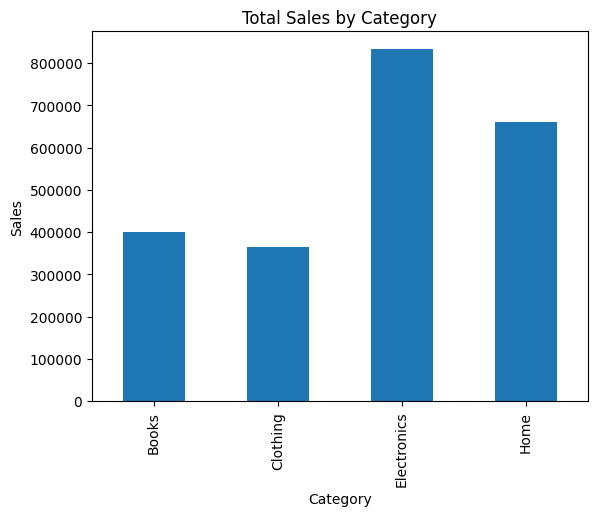

In [12]:
plt.figure()
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Price Distribution

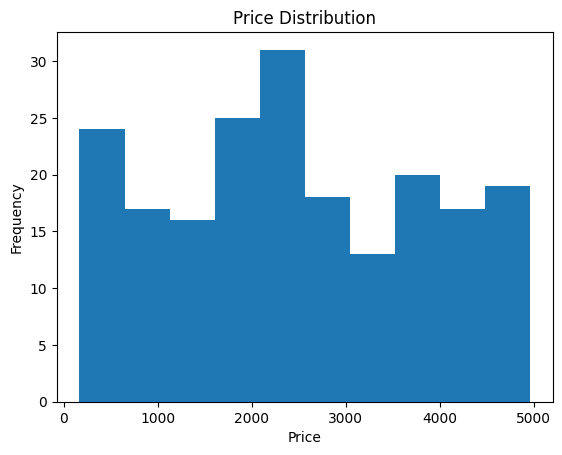

In [13]:
plt.figure()
plt.hist(df["Price"])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Correlation Heatmap

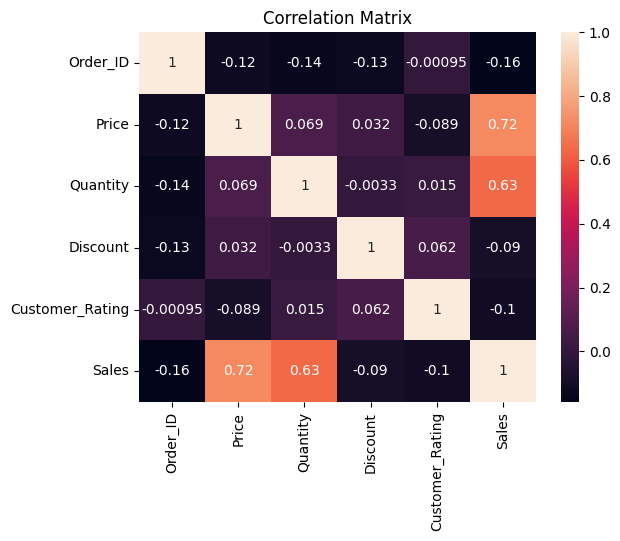

In [15]:
plt.figure()
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Part 1. Randomized Sales Data (NumPy)
Step 1- Initialize Random Seed

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(78)  

Step 2- Generate sales data

In [17]:
sales_data = np.random.randint(1000, 5000, size=(12, 4))

sales_data

array([[3757, 1470, 2943, 1040],
       [3153, 3358, 3744, 1541],
       [3164, 4476, 3163, 1078],
       [4843, 4596, 4704, 3091],
       [1708, 1148, 2110, 2638],
       [3848, 2015, 2027, 2062],
       [4140, 2497, 4479, 3206],
       [1578, 4484, 2613, 3455],
       [2182, 1163, 1101, 4356],
       [3005, 4130, 4217, 1322],
       [1340, 2629, 4198, 4881],
       [3352, 4872, 3124, 2206]], dtype=int32)

Step 3: Convert to DataFrame

In [18]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]

df = pd.DataFrame(sales_data, columns=columns, index=months)

df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3757,1470,2943,1040
Feb,3153,3358,3744,1541
Mar,3164,4476,3163,1078
Apr,4843,4596,4704,3091
May,1708,1148,2110,2638
Jun,3848,2015,2027,2062
Jul,4140,2497,4479,3206
Aug,1578,4484,2613,3455
Sep,2182,1163,1101,4356
Oct,3005,4130,4217,1322


A randomized dataset of monthly sales for four product categories was generated using NumPy and converted into a Pandas DataFrame.

Part II: Data Manipulation (Pandas)

In [19]:
df.head()

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3757,1470,2943,1040
Feb,3153,3358,3744,1541
Mar,3164,4476,3163,1078
Apr,4843,4596,4704,3091
May,1708,1148,2110,2638


In [20]:
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports
count,12.000000,12.000000,12.000000,12.000000
mean,3005.833333,3069.833333,3201.916667,2573.000000
std,1098.689288,1423.351476,1112.394425,1263.762924
min,1340.000000,1148.000000,1101.000000,1040.000000
25%,2063.500000,1878.750000,2487.250000,1486.250000
50%,3158.500000,2993.500000,3143.500000,2422.000000
75%,3779.750000,4478.000000,4202.750000,3268.250000
max,4843.000000,4872.000000,4704.000000,4881.000000


2. Total Sales
 Category-wise total

In [21]:
category_total = df.sum()
category_total

Electronics       36070
Clothing          36838
Home & Kitchen    38423
Sports            30876
dtype: int64

Month-wise total

In [22]:
monthly_total = df.sum(axis=1)
monthly_total

Jan     9210
Feb    11796
Mar    11881
Apr    17234
May     7604
Jun     9952
Jul    14322
Aug    12130
Sep     8802
Oct    12674
Nov    13048
Dec    13554
dtype: int64

In [23]:
growth = df.pct_change()
avg_growth = growth.mean()
avg_growth

Electronics       0.194853
Clothing          0.453121
Home & Kitchen    0.254330
Sports            0.365868
dtype: float64

In [24]:
# Total Sales per month
df["Total Sales"] = df.sum(axis=1)

# Growth Rate
df["Growth Rate"] = df["Total Sales"].pct_change() * 100

df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3757,1470,2943,1040,9210,NaN
Feb,3153,3358,3744,1541,11796,28.078176
Mar,3164,4476,3163,1078,11881,0.720583
Apr,4843,4596,4704,3091,17234,45.055130
May,1708,1148,2110,2638,7604,-55.877916
Jun,3848,2015,2027,2062,9952,30.878485
Jul,4140,2497,4479,3206,14322,43.910772
Aug,1578,4484,2613,3455,12130,-15.305125
Sep,2182,1163,1101,4356,8802,-27.436109
Oct,3005,4130,4217,1322,12674,43.990002


In [25]:
roll_number = 78 

if roll_number % 2 == 0:
    df["Electronics"] = df["Electronics"] * 0.9
else:
    df["Clothing"] = df["Clothing"] * 0.85

df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3381.3,1470,2943,1040,9210,NaN
Feb,2837.7,3358,3744,1541,11796,28.078176
Mar,2847.6,4476,3163,1078,11881,0.720583
Apr,4358.7,4596,4704,3091,17234,45.055130
May,1537.2,1148,2110,2638,7604,-55.877916
Jun,3463.2,2015,2027,2062,9952,30.878485
Jul,3726.0,2497,4479,3206,14322,43.910772
Aug,1420.2,4484,2613,3455,12130,-15.305125
Sep,1963.8,1163,1101,4356,8802,-27.436109
Oct,2704.5,4130,4217,1322,12674,43.990002


A conditional discount was applied based on the roll number to simulate real-world pricing strategies.

Part III: Visualizations

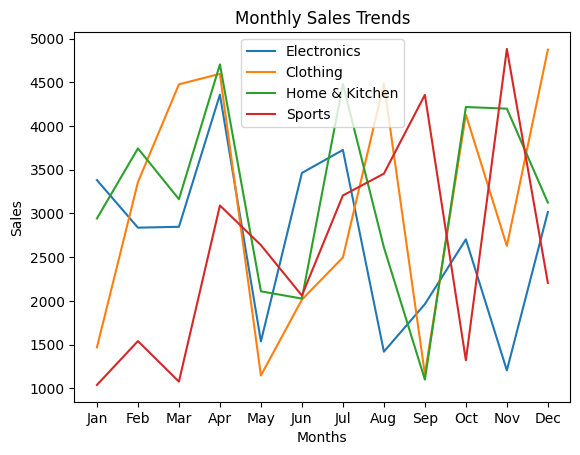

In [26]:
plt.figure()

for col in columns:
    plt.plot(df.index, df[col], label=col)

plt.title("Monthly Sales Trends")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.legend()
plt.show()

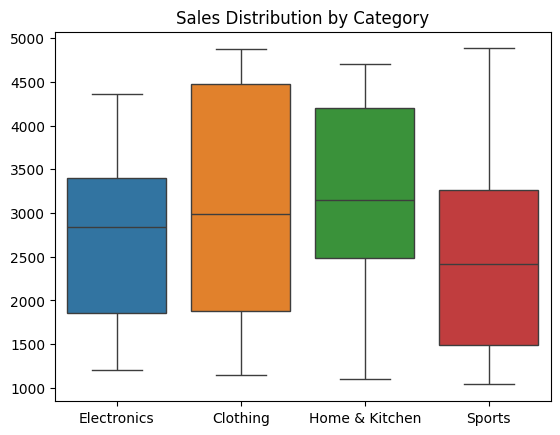

In [27]:
plt.figure()
sns.boxplot(data=df[columns])
plt.title("Sales Distribution by Category")
plt.show()

Sales trends fluctuate across months, showing seasonal variation.
Some categories show higher variability (visible in box plots).
Discounts slightly reduce category sales but may impact total sales trends.
Growth rate helps identify peak and low-performing months.

Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])
i. Find element-wise absolute value
ii. Find the 25th, 50th, and 75th percentile of flattened array, for each column, for each
row.
iii. Mean, Median and Standard Deviation of flattened array, of each column, and
each row

In [28]:
array = np.array([[1, -2, 3],
                  [-4, 5, -6]])

In [29]:
abs_array = np.abs(array)
print(abs_array)

[[1 2 3]
 [4 5 6]]


ii. Percentiles
 Flattened array

In [30]:
flat = array.flatten()

p25 = np.percentile(flat, 25)
p50 = np.percentile(flat, 50)
p75 = np.percentile(flat, 75)

print("Flattened Percentiles:", p25, p50, p75)

Flattened Percentiles: -3.5 -0.5 2.5


Column-wise

In [31]:
col_percentiles = np.percentile(array, [25, 50, 75], axis=0)
print("Column-wise Percentiles:\n", col_percentiles)

Column-wise Percentiles:
 [[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]


In [32]:
row_percentiles = np.percentile(array, [25, 50, 75], axis=1)
print("Row-wise Percentiles:\n", row_percentiles)

Row-wise Percentiles:
 [[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]


iii. Mean, Median, Std
👉 Flattened

In [33]:
print("Flattened Mean:", np.mean(flat))
print("Flattened Median:", np.median(flat))
print("Flattened Std:", np.std(flat))

Flattened Mean: -0.5
Flattened Median: -0.5
Flattened Std: 3.8622100754188224


COLUMN-WISE

In [34]:
print("Column Mean:", np.mean(array, axis=0))
print("Column Median:", np.median(array, axis=0))
print("Column Std:", np.std(array, axis=0))

Column Mean: [-1.5  1.5 -1.5]
Column Median: [-1.5  1.5 -1.5]
Column Std: [2.5 3.5 4.5]


Row-wise

In [35]:
print("Row Mean:", np.mean(array, axis=1))
print("Row Median:", np.median(array, axis=1))
print("Row Std:", np.std(array, axis=1))

Row Mean: [ 0.66666667 -1.66666667]
Row Median: [ 1. -4.]
Row Std: [2.05480467 4.78423336]


Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).
i. Find floor, ceiling and truncated value,rounded values

In [36]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])

In [37]:
print("Floor:", np.floor(a))
print("Ceil:", np.ceil(a))
print("Truncate:", np.trunc(a))
print("Round:", np.round(a))

Floor: [-2. -2. -1.  0.  1.  1.  3.]
Ceil: [-1. -1. -0.  1.  2.  2.  3.]
Truncate: [-1. -1. -0.  0.  1.  1.  3.]
Round: [-2. -2. -0.  0.  2.  2.  3.]


Q.4 WAP to swap two elementsin a list in Python Using a Temporary Variable.

In [38]:
lst = [10, 20, 30, 40]

# swap index 1 and 3
temp = lst[1]
lst[1] = lst[3]
lst[3] = temp

print(lst)

[10, 40, 30, 20]


Q.5 Write a Python program to swap two elementsin a set by converting it to a list first.

In [39]:
s = {10, 20, 30, 40}

lst = list(s)

# swap first two elements
lst[0], lst[1] = lst[1], lst[0]

# convert back to set
s = set(lst)

print(s)

{40, 10, 20, 30}
